# Tính chỉ số GSI (Greenwashing Severity Index) 
## từ Báo cáo Phát triển Bền vững của Ngân hàng Việt Nam

**Mục đích**: Tính toán chỉ số GSI dựa trên từ vựng E, S, G trong báo cáo ESG bằng phương pháp TF-IDF

**Luồng xử lý**:
1. Load PDF report → Chuyển sang text
2. Load từ vựa E, S, G từ Excel
3. Tiền xử lý text (Preprocessing)
4. Tính TF-IDF cho các từ khóa E, S, G
5. Tính ESG Focus Scores
6. Tính GSI = (ω_E × E_tfidf) + (ω_S × S_tfidf) + (ω_G × G_tfidf)

In [9]:
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

# PDF processing
try:
    import pdfplumber
    PDF_LIB = 'pdfplumber'
except ImportError:
    try:
        from PyPDF2 import PdfReader
        PDF_LIB = 'PyPDF2'
    except ImportError:
        PDF_LIB = None
        print("⚠️  Cảnh báo: Chưa cài pdfplumber hoặc PyPDF2. Cài đặt: pip install pdfplumber")

# TF-IDF calculation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

# Vietnamese text processing
try:
    import underthesea
    UNDERTHESEA_AVAILABLE = True
except ImportError:
    UNDERTHESEA_AVAILABLE = False
    print("⚠️  Cảnh báo: Chưa cài underthesea. Cài đặt: pip install underthesea")

print("✅ Import libraries thành công")

✅ Import libraries thành công


## 1️⃣  LOAD FILE TEXT BÁO CÁO (Đã trích xuất từ PDF ở Luồng 1)

Hướng dẫn:
1. Thay `REPORT_TEXT_FILE` bằng đường dẫn tới file text báo cáo đã được trích xuất ở Luồng 1.
   - Ví dụ: `r"D:\NCKH\extracted_text.txt"` 
2. Thay `OUTPUT_DIR` bằng đường dẫn thư mục bạn muốn lưu file kết quả.

In [10]:
# =====================================================================
# CẤU HÌNH: ĐƯỜNG DẪN FILE TEXT VÀ THƯ MỤC OUTPUT
# =====================================================================
# TODO: Thay đường dẫn này bằng đường dẫn file text từ Luồng 1
REPORT_TEXT_FILE = r"D:\NCKH\ESG_reporting\extracted_texts\BIDV_2023_ESG_raw.txt"  

# Tự động trích xuất tên ngân hàng và năm từ tên file (Format: bank_năm_ESG...)
# Ví dụ: BIDV_2023_ESG_raw.txt -> bank = BIDV, năm = 2023
try:
    base_name = os.path.basename(REPORT_TEXT_FILE)
    parts = base_name.split('_')
    bank_name = parts[0]
    year = parts[1]
except Exception as e:
    bank_name = "UnknownBank"
    year = "UnknownYear"

# Thư mục lưu kết quả: outputs/{năm}/{bank}/
OUTPUT_DIR = os.path.join(r"D:\NCKH\Thread_2\outputs", year, bank_name)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📁 Thư mục output được set thành: {OUTPUT_DIR}")
# =====================================================================

def load_text_from_file(file_path):
    """
    Load toàn bộ text từ file .txt (đã được extract từ PDF ở Luồng 1)
    """
    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file: {file_path}")
        return None
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
        return text
    except Exception as e:
        print(f"❌ Lỗi khi đọc file: {e}")
        return None

# Thực hiện load text
print(f"📄 Đang đọc file text: {os.path.basename(REPORT_TEXT_FILE)}")
report_text = load_text_from_file(REPORT_TEXT_FILE)

if report_text:
    print(f"✅ Đã đọc xong! Tổng {len(report_text)} ký tự")
    print(f"\n📝 Preview 500 ký tự đầu tiên:\n{report_text[:500]}...")
else:
    print("❌ Không thể đọc text từ file")

📁 Thư mục output được set thành: D:\NCKH\Thread_2\outputs\2023\BIDV
📄 Đang đọc file text: BIDV_2023_ESG_raw.txt
✅ Đã đọc xong! Tổng 223364 ký tự

📝 Preview 500 ký tự đầu tiên:
KIẾN TẠO
TƯƠNG LAI
NGÂN HÀNG TMCP ĐẦU TƯ VÀ PHÁT TRIỂN VIỆT NAM
TRỤ SỞ CHÍNH: Tháp BIDV, 194 Trần Quang Khải, Hoàn Kiếm, Hà Nội
ĐIỆN THOẠI: 024 2220 5544
HOTLINE: 19009247
WEBSITE: https://www.bidv.comvn
BÁO CÁO PHÁT TRIỂN BỀN VỮNG BIDV 2023 ĐƯỢC ĐĂNG TẠI ĐỊA CHỈ:
https://www.bidv.com.vn/vn/quan-he-nha-dau-tu/ hoặc quét mã QR code:
BIÊN TẬP: BAN THƯ KÝ HỘI ĐỒNG QUẢN TRỊ VÀ QUAN HỆ CỔ ĐÔNG
BÁO
CÁO
PHÁT
TRIỂN
BỀN
VỮNG
2023
BÁO CÁO
PHÁT TRIỂN BỀN VỮNG 2023
1.Trần Nguyệt Quỳnh Hoa, Head of IR (email...


## 2️⃣ LOAD TỪ VỰNG E, S, G TỪ EXCEL FILES

Hướng dẫn:
1. Chuẩn bị 3 file Excel chứa từ vựng:
   - File E (Environmental - Môi trường): `A2_Environment_Keywords.xlsx` hoặc tương tự
   - File S (Social - Xã hội): `A3_Social_Keywords.xlsx`
   - File G (Governance - Quản trị): `A4_Governance_Keywords.xlsx`

2. Cấu trúc Excel:

3. Thay đường dẫn files dưới đây

In [11]:
# =====================================================================
# CẤU HÌNH: ĐƯỜNG DẪN EXCEL FILES CHỨA TỪ VỰNG E, S, G
# =====================================================================
# TODO: Thay đường dẫn này bằng đường dẫn files của bạn
E_KEYWORDS_FILE = r"D:\NCKH\ESG_Dictionary\E.xlsx"      # VD: r"d:\NCKH\Data\E_keywords.xlsx"
S_KEYWORDS_FILE = r"D:\NCKH\ESG_Dictionary\S.xlsx"           # VD: r"d:\NCKH\Data\S_keywords.xlsx"
G_KEYWORDS_FILE = r"D:\NCKH\ESG_Dictionary\G.xlsx"       # VD: r"d:\NCKH\Data\G_keywords.xlsx"

# =====================================================================

def load_keywords_from_excel(excel_path):
    """
    Load từ vựng từ Excel file (chỉ đọc cột đầu tiên)
    
    Args:
        excel_path: Đường dẫn file Excel
        
    Returns:
        Danh sách keywords (lowercase)
    """
    if not os.path.exists(excel_path):
        raise FileNotFoundError(f"❌ Không tìm thấy file: {excel_path}")
    
    try:
        df = pd.read_excel(excel_path)
        
        # Lấy cột đầu tiên (cột duy nhất chứa keywords)
        first_column = df.columns[0]
        
        print(f"   📋 File: {os.path.basename(excel_path)}")
        print(f"      Cột được sử dụng: '{first_column}'")
        
        # Extract keywords từ cột đầu tiên
        keywords = df[first_column].dropna().astype(str).str.lower().str.strip().tolist()
        keywords = [kw for kw in keywords if kw and kw != 'nan']  # Loại bỏ string rỗng
        
        print(f"   ✅ Loaded {len(keywords)} keywords")
        return keywords
    
    except Exception as e:
        print(f"   ❌ Lỗi khi load Excel: {e}")
        return []

# Load từ vựng từ 3 file
print("📂 Đang load từ vựng E, S, G từ Excel files...")
print("=" * 60)

E_keywords = load_keywords_from_excel(E_KEYWORDS_FILE)
S_keywords = load_keywords_from_excel(S_KEYWORDS_FILE)
G_keywords = load_keywords_from_excel(G_KEYWORDS_FILE)

print("=" * 60)
print(f"\n📊 Tóm tắt từ vựng:")
print(f"   🌍 E (Environment - Môi trường): {len(E_keywords)} keywords")
print(f"   👥 S (Social - Xã hội):          {len(S_keywords)} keywords")
print(f"   ⚖️  G (Governance - Quản trị):    {len(G_keywords)} keywords")
print(f"   📈 Tổng: {len(E_keywords) + len(S_keywords) + len(G_keywords)} keywords")

# Preview
print(f"\n🔍 Preview từ vựng:")
print(f"   E sample: {E_keywords[:5] if E_keywords else 'N/A'}")
print(f"   S sample: {S_keywords[:5] if S_keywords else 'N/A'}")
print(f"   G sample: {G_keywords[:5] if G_keywords else 'N/A'}")

📂 Đang load từ vựng E, S, G từ Excel files...
   📋 File: E.xlsx
      Cột được sử dụng: 'ENVIRONMENT '
   ✅ Loaded 186 keywords
   📋 File: S.xlsx
      Cột được sử dụng: 'SOCIAL'
   ✅ Loaded 383 keywords
   📋 File: G.xlsx
      Cột được sử dụng: 'GOVERNMENT'
   ✅ Loaded 153 keywords

📊 Tóm tắt từ vựng:
   🌍 E (Environment - Môi trường): 186 keywords
   👥 S (Social - Xã hội):          383 keywords
   ⚖️  G (Governance - Quản trị):    153 keywords
   📈 Tổng: 722 keywords

🔍 Preview từ vựng:
   E sample: ['tiết kiệm nước', 'mô hình không rác thải', 'không chất thải', 'công nghệ phát thải thấp', 'bảo tồn tài nguyên đất']
   S sample: ['doanh nghiệp có trách nhiệm với xã hội', 'trách nhiệm xã hội của doanh nghiệp', 'vai trò công dân của doanh nghiệp', 'doanh nghiệp công dân', 'hỗ trợ cân bằng giữa công việc và cuộc sống gia đình']
   G sample: ['chống hối lộ', 'chống tham nhũng', 'chính sách chống gian lận', 'chống gian lận', 'chống rửa tiền']


## 3️⃣ TIỀN XỬ LÝ TEXT (PREPROCESSING)

Các bước preprocessing:
- Chuyển thường (Lowercasing)
- Chuẩn hóa dấu câu (Punctuation normalization)
- Tokenization (Tách thành từ)
- Lemmatization (Đưa về dạng gốc)
- Loại bỏ stopwords vô nghĩa

In [12]:
# Danh sách stopwords tiếng Việt cơ bản
VIETNAMESE_STOPWORDS = {
    'và', 'của', 'là', 'được', 'có', 'cái', 'chiếc', 'chiếu', 'cách', 'cái',
    'để', 'từ', 'do', 'đến', 'đó', 'về', 'sau', 'trước', 'trên', 'dưới',
    'như', 'nhưng', 'nếu', 'với', 'khi', 'mà', 'cũng', 'hay', 'vừa', 'hoặc',
    'nên', 'hoặc', 'thì', 'tại', 'ở', 'qua', 'ra', 'vào', 'lên', 'xuống',
    'người', 'năm', 'tháng', 'ngày', 'giờ', 'phút', 'giây',
    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'by', 'for', 'from',
    'has', 'he', 'in', 'is', 'it', 'of', 'on', 'or', 'that', 'the',
    'to', 'was', 'will', 'with', 'or', 'the', 'this', 'but', 'they', 'we'
}

def preprocess_text(text):
    """
    Tiền xử lý text tiếng Việt
    
    Args:
        text: Text cần xử lý
        
    Returns:
        Text đã xử lý (lowercase, tokenized)
    """
    if not text:
        return ""
    
    # 1. Chuyển thường
    text = text.lower()
    
    # 2. Chuẩn hóa dấu câu (giữ lại khoảng trắng)
    text = re.sub(r'[^\w\s]', ' ', text)  # Thay punctuation bằng space
    text = re.sub(r'\s+', ' ', text)       # Gom nhiều space thành 1
    
    # 3. Tokenization
    tokens = text.split()
    
    # 4. Loại bỏ stopwords
    tokens = [token for token in tokens if token not in VIETNAMESE_STOPWORDS and len(token) > 1]
    
    return tokens

# Thực hiện preprocessing
print("🔄 Đang tiền xử lý text báo cáo...")
if report_text:
    processed_tokens = preprocess_text(report_text)
    print(f"✅ Preprocessing xong!")
    print(f"   📊 Tổng tokens: {len(processed_tokens)}")
    print(f"   📝 Độ dài sentence average: {np.mean([len(t) for t in processed_tokens if t]):.1f} ký tự")
    print(f"   🔤 Preview 20 tokens đầu: {processed_tokens[:20]}")
else:
    print("❌ Không có text để xử lý")

🔄 Đang tiền xử lý text báo cáo...
✅ Preprocessing xong!
   📊 Tổng tokens: 42700
   📝 Độ dài sentence average: 3.6 ký tự
   🔤 Preview 20 tokens đầu: ['kiến', 'tạo', 'tương', 'lai', 'ngân', 'hàng', 'tmcp', 'đầu', 'tư', 'phát', 'triển', 'việt', 'nam', 'trụ', 'sở', 'chính', 'tháp', 'bidv', '194', 'trần']


## 4️⃣ TÍNH CHỈ SỐ GSI (GREENWASHING SEVERITY INDEX)

⚠️ **Cập nhật**:  Algorithm hiện hỗ trợ tìm kiếm **cụm từ (multi-word phrases)** từ file E, S, G của bạn. Ví dụ: "Chống hối lộ và tham nhũng" sẽ được tìm đúng trong báo cáo, không chỉ từ đơn lẻ.

### Bước 4.1: Tính TF-IDF cho các từ khóa E, S, G

**Công thức TF-IDF**:
$$TF(t,d) = \frac{f_{t,d}}{N_d}$$
$$IDF(t,D) = \log\left(\frac{N_D}{n_t}\right)$$
$$TF-IDF(t,d,D) = TF(t,d) \times IDF(t,D)$$

**ESG Focus Scores**:
$$E_{tfidf} = \sum_{t \in E} TF-IDF(t,d,D)$$
$$S_{tfidf} = \sum_{t \in S} TF-IDF(t,d,D)$$
$$G_{tfidf} = \sum_{t \in G} TF-IDF(t,d,D)$$

### Bước 4.2: Tính GSI Index

**Công thức GSI**:
$$GSI = (\omega_E \times E_{tfidf}) + (\omega_S \times S_{tfidf}) + (\omega_G \times G_{tfidf})$$

Trong đó: $\omega_E = \omega_S = \omega_G = \frac{1}{3} = 0.333$

In [17]:
def calculate_tfidf_focus_scores(text, tokens, E_keywords, S_keywords, G_keywords):
    """
    Tính TF-IDF Focus Scores cho E, S, G
    
    Lưu ý: Hỗ trợ tìm kiếm cả từ đơn lẻ và cụm từ (multi-word phrases)
    
    Args:
        text: Text gốc đã tiền xử lý (lowercase)
        tokens: Danh sách tokens từ text đã preprocess
        E_keywords, S_keywords, G_keywords: Danh sách keywords từng loại (có thể chứa cụm từ)
        
    Returns:
        Dict chứa E_tfidf, S_tfidf, G_tfidf scores
    """
    
    # Kết hợp tất cả keywords
    all_keywords = E_keywords + S_keywords + G_keywords
    all_keywords_set = set(all_keywords)
    
    # Tính TF cho từng keyword bằng cách đếm số lần xuất hiện trong text
    token_counts = {}
    
    for keyword in all_keywords:
        # Xóa stopwords từ keyword để tìm kiếm chính xác hơn
        keyword_lower = keyword.lower().strip()
        
        # Tìm kiếm keyword trong text gốc
        # Count occurrences by splitting text and searching
        count = 0
        search_text = text + " "  # Thêm space cuối để tìm keyword ở cuối text
        keyword_pattern = keyword_lower + " "
        
        # Simple counting: split by space và tìm keyword
        text_words = text.split()
        for i in range(len(text_words)):
            # Ghép các từ liên tiếp để check cụm từ
            if len(keyword_lower.split()) == 1:
                # Keyword là từ đơn lẻ
                if text_words[i] == keyword_lower:
                    count += 1
            else:
                # Keyword là cụm từ - ghép các từ liên tiếp
                num_words = len(keyword_lower.split())
                if i + num_words <= len(text_words):
                    phrase = " ".join(text_words[i:i+num_words])
                    if phrase == keyword_lower:
                        count += 1
        
        if count > 0:
            token_counts[keyword] = count
    
    print(f"   📊 Tìm thấy keywords:")
    print(f"      - E keywords: {sum(1 for kw in E_keywords if kw in token_counts)} / {len(E_keywords)}")
    print(f"      - S keywords: {sum(1 for kw in S_keywords if kw in token_counts)} / {len(S_keywords)}")
    print(f"      - G keywords: {sum(1 for kw in G_keywords if kw in token_counts)} / {len(G_keywords)}")
    
    total_tokens = len(tokens)
    
    # Tính TF (Term Frequency)
    tf_scores = {}
    for keyword, count in token_counts.items():
        tf_scores[keyword] = count / max(total_tokens, 1)
    
    # IDF (Inverse Document Frequency)
    idf_scores = {}
    for keyword in all_keywords:
        freq = token_counts.get(keyword, 0)
        # IDF = log(total_keywords / (1 + freq))
        idf_scores[keyword] = np.log((len(all_keywords) + 1) / (freq + 1))
    
    # TF-IDF = TF × IDF
    tfidf_scores = {}
    for keyword in all_keywords:
        tf = tf_scores.get(keyword, 0)
        idf = idf_scores.get(keyword, 0)
        tfidf_scores[keyword] = tf * idf
    
    # Tính ESG Focus Scores
    E_tfidf = sum(tfidf_scores.get(kw, 0) for kw in E_keywords)
    S_tfidf = sum(tfidf_scores.get(kw, 0) for kw in S_keywords)
    G_tfidf = sum(tfidf_scores.get(kw, 0) for kw in G_keywords)
    
    # TRẢ VỀ ĐIỂM GỐC (Không chuẩn hóa cục bộ ở đây để phục vụ Clustering chéo)
    return {
        'E_tfidf': E_tfidf,
        'S_tfidf': S_tfidf,
        'G_tfidf': G_tfidf,
        'E_tfidf_norm': E_tfidf,  # Giữ nguyên tên key để không lỗi code phía dưới
        'S_tfidf_norm': S_tfidf,
        'G_tfidf_norm': G_tfidf,
        'tf_scores': tf_scores,
        'tfidf_scores': tfidf_scores,
        'token_counts': token_counts
    }


def calculate_gsi(E_tfidf, S_tfidf, G_tfidf, normalize=True):
    """
    Tính chỉ số GSI (Greenwashing Severity Index)
    
    Công thức: GSI = (ω_E × E_tfidf) + (ω_S × S_tfidf) + (ω_G × G_tfidf)
               Với: ω_E = ω_S = ω_G = 1/3 (weights bằng nhau)
    
    Args:
        E_tfidf: ESG Focus Score cho Environment
        S_tfidf: ESG Focus Score cho Social
        G_tfidf: ESG Focus Score cho Governance
        normalize: Có chuẩn hóa về 0-1 không
        
    Returns:
        GSI score (float)
    """
    
    # Trọng số bằng nhau cho E, S, G
    omega_E = omega_S = omega_G = 1/3
    
    # Tính GSI
    GSI = (omega_E * E_tfidf) + (omega_S * S_tfidf) + (omega_G * G_tfidf)
    
    # Normalize về 0-1 nếu cần
    if normalize:
        max_possible = (1/3) * 3  # Maximum possible GSI
        GSI_normalized = min(GSI / max(max_possible, 1e-6), 1.0) if max_possible > 0 else 0
        return GSI_normalized
    
    return GSI


# ========================================================
# THỰC HIỆN TÍNH TOÁN
# ========================================================
print("🔢 Đang tính GSI scores...")
print("=" * 60)

if report_text and E_keywords and S_keywords and G_keywords:
    # Tính TF-IDF Focus Scores (truyền cả text gốc, không chỉ tokens)
    print("📂 Đang tính toán TF-IDF scores...")
    focus_scores = calculate_tfidf_focus_scores(
        report_text,          # Text gốc đã lowercase
        processed_tokens,     # Tokens array
        E_keywords, 
        S_keywords, 
        G_keywords
    )
    
    E_tfidf = focus_scores['E_tfidf_norm']
    S_tfidf = focus_scores['S_tfidf_norm']
    G_tfidf = focus_scores['G_tfidf_norm']
    
    # Tính GSI (Bỏ normalize do dùng điểm raw cho Clustering)
    GSI_score = calculate_gsi(E_tfidf, S_tfidf, G_tfidf, normalize=False)
    
    # Hiển thị kết quả
    print("📊 KẾT QUẢ TÍNH TOÁN GSI")
    print("=" * 60)
    print(f"\n🌍 ESG Focus Scores (Raw TF-IDF):")
    print(f"   E (Environment - Môi trường): {E_tfidf:.6f}")
    print(f"   S (Social - Xã hội):          {S_tfidf:.6f}")
    print(f"   G (Governance - Quản trị):    {G_tfidf:.6f}")
    
    print(f"\n🎯 Greenwashing Severity Index (Raw GSI):")
    print(f"   GSI Score: {GSI_score:.6f}")
    
    print("\n💡 Lưu ý: Điểm số hiện tại là điểm thô (Raw). Việc phân loại mức độ Greenwashing (Cao/Thấp/Trung bình) sẽ được thực hiện thống nhất ở bước K-Means Clustering.")
    
    print("\n" + "=" * 60)
    
else:
    print("❌ Lỗi: Thiếu dữ liệu để tính toán")
    print("   Kiểm tra lại:")
    print(f"   - Report text: {len(report_text) if report_text else 0} characters")
    print(f"   - E keywords: {len(E_keywords)}")
    print(f"   - S keywords: {len(S_keywords)}")
    print(f"   - G keywords: {len(G_keywords)}")

🔢 Đang tính GSI scores...
📂 Đang tính toán TF-IDF scores...
   📊 Tìm thấy keywords:
      - E keywords: 20 / 186
      - S keywords: 16 / 383
      - G keywords: 18 / 153
📊 KẾT QUẢ TÍNH TOÁN GSI

🌍 ESG Focus Scores (Raw TF-IDF):
   E (Environment - Môi trường): 0.017630
   S (Social - Xã hội):          0.005169
   G (Governance - Quản trị):    0.013448

🎯 Greenwashing Severity Index (Raw GSI):
   GSI Score: 0.012082

💡 Lưu ý: Điểm số hiện tại là điểm thô (Raw). Việc phân loại mức độ Greenwashing (Cao/Thấp/Trung bình) sẽ được thực hiện thống nhất ở bước K-Means Clustering.



In [18]:

# ========================================================
# DEBUG: Kiểm tra chi tiết keywords được tìm thấy
# ========================================================
print("\n" + "="*60)
print("🔍 DEBUG: CHI TIẾT KEYWORDS TÌM THẤY")
print("="*60)

if 'focus_scores' in locals():
    found_keywords = focus_scores['token_counts']
    
    if found_keywords:
        print(f"\n✅ Tìm thấy {len(found_keywords)} keywords trong báo cáo:")
        print(f"\nDanh sách chi tiết:")
        
        # Sort by occurrence count
        sorted_keywords = sorted(found_keywords.items(), key=lambda x: x[1], reverse=True)
        for i, (kw, count) in enumerate(sorted_keywords, 1):
            # Determine which category (E, S, or G)
            category = ""
            if kw in E_keywords:
                category = "E (Environment)"
            elif kw in S_keywords:
                category = "S (Social)"
            elif kw in G_keywords:
                category = "G (Governance)"
            
            print(f"  {i}. [{category}] '{kw}': {count} lần")
    else:
        print("\n❌ KHÔNG tìm thấy keywords nào!")
        print("\n💡 Kiểm tra lại:")
        print(f"   - File E: {len(E_keywords)} keywords")
        print(f"   - File S: {len(S_keywords)} keywords") 
        print(f"   - File G: {len(G_keywords)} keywords")
        print(f"\n   - Preview E keywords đầu tiên: {E_keywords[:3]}")
        print(f"   - Preview S keywords đầu tiên: {S_keywords[:3]}")
        print(f"   - Preview G keywords đầu tiên: {G_keywords[:3]}")
else:
    print("⚠️  Chưa tính toán focus_scores")


🔍 DEBUG: CHI TIẾT KEYWORDS TÌM THẤY

✅ Tìm thấy 51 keywords trong báo cáo:

Danh sách chi tiết:
  1. [G (Governance)] 'tuân thủ': 74 lần
  2. [E (Environment)] 'phát triển bền vững': 47 lần
  3. [G (Governance)] 'quản lý rủi ro': 28 lần
  4. [G (Governance)] 'minh bạch': 17 lần
  5. [E (Environment)] 'giảm phát thải': 15 lần
  6. [E (Environment)] 'bảo vệ môi trường': 14 lần
  7. [E (Environment)] 'biến đổi khí hậu': 11 lần
  8. [G (Governance)] 'văn hóa doanh nghiệp': 11 lần
  9. [G (Governance)] 'tuân thủ quy định': 10 lần
  10. [E (Environment)] 'khí nhà kính': 9 lần
  11. [G (Governance)] 'chống tham nhũng': 9 lần
  12. [E (Environment)] 'năng lượng sạch': 8 lần
  13. [E (Environment)] 'quản lý rủi ro môi trường': 8 lần
  14. [S (Social)] 'quản trị nguồn nhân lực': 8 lần
  15. [E (Environment)] 'tiết kiệm năng lượng': 7 lần
  16. [E (Environment)] 'thân thiện với môi trường': 7 lần
  17. [E (Environment)] 'phát thải khí nhà kính': 7 lần
  18. [E (Environment)] 'năng lượng tái tạo'

## 5️⃣ VISUALIZATION VÀ TỔNG HỢP KẾT QUẢ

Hiển thị biểu đồ các thành phần ESG và GSI score

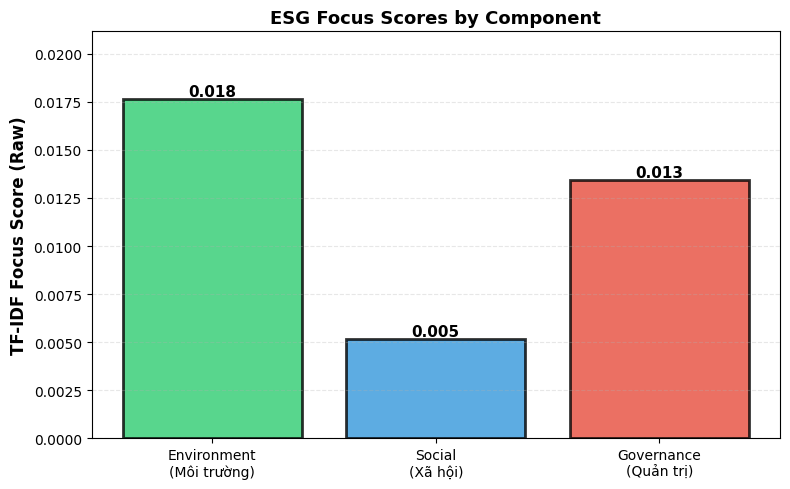

✅ Biểu đồ đã được lưu vào 'D:\NCKH\Thread_2\outputs\2023\BIDV\GSI_Report.png'


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import os

# Set font cho hỗ trợ tiếng Việt
try:
    rcParams['font.sans-serif'] = ['DejaVu Sans', 'Times New Roman']
except:
    pass

# Đảm bảo OUTPUT_DIR tồn tại
if 'OUTPUT_DIR' not in locals():
    # Tạo biến tạm nếu lỡ chưa chạy cell đầu
    OUTPUT_DIR = r"D:\NCKH\Thread_2\outputs\UnknownYear\UnknownBank" 
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Tạo visualization
if 'GSI_score' in locals() and GSI_score is not None:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # Chart 1: ESG Component Scores
    components = ['Environment\n(Môi trường)', 'Social\n(Xã hội)', 'Governance\n(Quản trị)']
    scores = [E_tfidf, S_tfidf, G_tfidf]
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    
    bars = ax1.bar(components, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax1.set_ylabel('TF-IDF Focus Score (Raw)', fontsize=12, fontweight='bold')
    ax1.set_title('ESG Focus Scores by Component', fontsize=13, fontweight='bold')
    ax1.set_ylim(0, max(scores) * 1.2 if max(scores) > 0 else 1)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    chart_output_path = os.path.join(OUTPUT_DIR, 'GSI_Report.png')
    plt.savefig(chart_output_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Biểu đồ đã được lưu vào '{chart_output_path}'")

else:
    print("❌ Không thể vẽ biểu đồ vì chưa tính GSI")

## 6️⃣ XUẤT KẾT QUẢ VÀO FILE

Lưu kết quả GSI vào CSV file để sử dụng sau

In [22]:
import os
import json

# Đảm bảo OUTPUT_DIR tồn tại
if 'OUTPUT_DIR' not in locals():
    OUTPUT_DIR = r"D:\NCKH\Thread_2\outputs\UnknownYear\UnknownBank"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Tạo DataFrame kết quả
if 'GSI_score' in locals() and GSI_score is not None:
    results_df = pd.DataFrame({
        'Metric': [
            'E (Environment) TF-IDF Score',
            'S (Social) TF-IDF Score',
            'G (Governance) TF-IDF Score',
            'GSI (Greenwashing Severity Index)',
            'Total Tokens Analyzed',
            'Total Keywords Found',
            'Total E Keywords Found',
            'Total S Keywords Found',
            'Total G Keywords Found'
        ],
        'Value': [
            f'{E_tfidf:.6f}',
            f'{S_tfidf:.6f}',
            f'{G_tfidf:.6f}',
            f'{GSI_score:.6f}',
            str(len(processed_tokens)),
            str(len(focus_scores['token_counts'])),
            str(sum(1 for kw in E_keywords if kw in focus_scores['token_counts'])),
            str(sum(1 for kw in S_keywords if kw in focus_scores['token_counts'])),
            str(sum(1 for kw in G_keywords if kw in focus_scores['token_counts']))
        ]
    })
    
    # Tìm các keywords được sử dụng nhiều nhất
    print("\n📄 TOP KEYWORDS FOUND IN REPORT:")
    print("=" * 60)
    
    # E keywords
    e_found = {kw: focus_scores['token_counts'].get(kw, 0) for kw in E_keywords}
    e_found_sorted = sorted(e_found.items(), key=lambda x: x[1], reverse=True)[:10]
    if e_found_sorted and max((count for _, count in e_found_sorted), default=0) > 0:
        print(f"\n🌍 Top Environment Keywords:")
        for kw, count in e_found_sorted:
            if count > 0:
                print(f"   - '{kw}': {count} occurrences")
    else:
        print(f"\n🌍 Top Environment Keywords: Không tìm thấy keywords")
    
    # S keywords
    s_found = {kw: focus_scores['token_counts'].get(kw, 0) for kw in S_keywords}
    s_found_sorted = sorted(s_found.items(), key=lambda x: x[1], reverse=True)[:10]
    if s_found_sorted and max((count for _, count in s_found_sorted), default=0) > 0:
        print(f"\n👥 Top Social Keywords:")
        for kw, count in s_found_sorted:
            if count > 0:
                print(f"   - '{kw}': {count} occurrences")
    else:
        print(f"\n👥 Top Social Keywords: Không tìm thấy keywords")
    
    # G keywords
    g_found = {kw: focus_scores['token_counts'].get(kw, 0) for kw in G_keywords}
    g_found_sorted = sorted(g_found.items(), key=lambda x: x[1], reverse=True)[:10]
    if g_found_sorted and max((count for _, count in g_found_sorted), default=0) > 0:
        print(f"\n⚖️  Top Governance Keywords:")
        for kw, count in g_found_sorted:
            if count > 0:
                print(f"   - '{kw}': {count} occurrences")
    else:
        print(f"\n⚖️  Top Governance Keywords: Không tìm thấy keywords")
    
    # Xuất kết quả ra CSV
    output_csv = os.path.join(OUTPUT_DIR, "GSI_Results.csv")
    results_df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"\n✅ Kết quả đã được lưu vào '{output_csv}'")
    
    # Xuất chi tiết hơn
    detailed_results = {
        'Report Summary': {
            'Text File': os.path.basename(REPORT_TEXT_FILE) if 'REPORT_TEXT_FILE' in locals() else 'Unknown',
            'Total Characters': len(report_text),
            'Total Tokens': len(processed_tokens),
            'Date Calculated': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
        },
        'ESG Scores': {
            'E_tfidf': float(E_tfidf),
            'S_tfidf': float(S_tfidf),
            'G_tfidf': float(G_tfidf),
        },
        'GSI Score': {
            'GSI_Raw': float(GSI_score),
            'Risk Level': 'Pending Clustering'
        },
        'Keywords Found': {
            'Total': len(focus_scores['token_counts']),
            'E Keywords': sum(1 for kw in E_keywords if kw in focus_scores['token_counts']),
            'S Keywords': sum(1 for kw in S_keywords if kw in focus_scores['token_counts']),
            'G Keywords': sum(1 for kw in G_keywords if kw in focus_scores['token_counts'])
        }
    }
    
    # Xuất dạng JSON cho tiện
    output_json = os.path.join(OUTPUT_DIR, "GSI_Results.json")
    with open(output_json, 'w', encoding='utf-8') as f:
        json.dump(detailed_results, f, ensure_ascii=False, indent=2)
    print(f"✅ Chi tiết kết quả đã được lưu vào '{output_json}'")
    
else:
    print("❌ Không có kết quả GSI để xuất")


📄 TOP KEYWORDS FOUND IN REPORT:

🌍 Top Environment Keywords:
   - 'phát triển bền vững': 47 occurrences
   - 'giảm phát thải': 15 occurrences
   - 'bảo vệ môi trường': 14 occurrences
   - 'biến đổi khí hậu': 11 occurrences
   - 'khí nhà kính': 9 occurrences
   - 'năng lượng sạch': 8 occurrences
   - 'quản lý rủi ro môi trường': 8 occurrences
   - 'tiết kiệm năng lượng': 7 occurrences
   - 'thân thiện với môi trường': 7 occurrences
   - 'phát thải khí nhà kính': 7 occurrences

👥 Top Social Keywords:
   - 'quản trị nguồn nhân lực': 8 occurrences
   - 'quyền con người': 6 occurrences
   - 'an toàn lao động': 5 occurrences
   - 'phát triển nghề nghiệp': 4 occurrences
   - 'giá trị cộng đồng': 4 occurrences
   - 'hoạt động vì cộng đồng': 4 occurrences
   - 'bình đẳng giới': 2 occurrences
   - 'trách nhiệm xã hội': 2 occurrences
   - 'sức khỏe và an toàn': 2 occurrences
   - 'lao động trẻ em': 1 occurrences

⚖️  Top Governance Keywords:
   - 'tuân thủ': 74 occurrences
   - 'quản lý rủi ro':

## 📝 NOTES VÀ HƯỚNG DẪN TIẾP THEO

### Cách sử dụng notebook:

1. **Bước 1**: Chuẩn bị dữ liệu
   - PDF ( đã chuyển sang text) báo cáo bền vững của ngân hàng
   - 3 file Excel chứa từ vựng E, S, G (tiếng Việt)

2. **Bước 2**: Điền đường dẫn file
   - Mở cell "LOAD VÀ CHUYỂN ĐỔI PDF" → Điền `PDF_FILE_PATH`
   - Mở cell "LOAD TỪ VỰNG E, S, G" → Điền 3 đường dẫn Excel

3. **Bước 3**: Chạy hết tất cả cells từ trên xuống dưới

4. **Bước 4**: Xem kết quả
   - GSI Score được in ra console
   - Biểu đồ được vẽ
   - CSV file được lưu